In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv("tanks_data.csv")

data['Type'] = data['Type'].replace({
    'Artillery': 'Group_1',
    'Tank Destroyer': 'Group_1',
    'Light Tank': 'Group_2',
    'Medium Tank': 'Group_2',
    'Heavy Tank': 'Group_2'
})

X = data.drop(columns=['Type', 'Name'])
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [2]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

score = log_model.score(X_test, y_test)
print(score)

0.964


In [2]:
from sklearn.model_selection import RandomizedSearchCV
from LinearRegressionClassifier import LinearClassifierGD
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer
import numpy as np

param_dist_linear = {
    'alpha': np.random.uniform(0.1, 1.0, 10),
    'lambda_': np.random.uniform(0.001, 0.1, 10),
    'learning_rate': np.random.uniform(0.001, 0.1, 10),
    'loss': ['logistic', 'squared', 'linear']
}

linear_model = LinearClassifierGD(max_iter=3000)
scorer = make_scorer(accuracy_score)

random_search_linear = RandomizedSearchCV(estimator=linear_model, param_distributions=param_dist_linear,
                                          n_iter=20, cv=3, scoring=scorer, verbose=1, random_state=42)
random_search_linear.fit(X_train, y_train)

print(f"Best Parameters: {random_search_linear.best_params_}")
print(f"Best Cross-validation Score: {random_search_linear.best_score_}")

#Best Parameters: {'loss': 'squared', 'learning_rate': np.float64(0.009973660315651944), 'lambda_': np.float64(0.01451552758559058), 'alpha': np.float64(0.4106826557795271)}
#Best Cross-validation Score: 0.9611780455153949

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'max_iter': np.int64(2000), 'loss': 'squared', 'learning_rate': np.float64(0.009973660315651944), 'lambda_': np.float64(0.01451552758559058), 'alpha': np.float64(0.4106826557795271)}
Best Cross-validation Score: 0.9611780455153949


In [9]:
from sklearn.model_selection import RandomizedSearchCV
from LinearRegressionClassifier import SVMClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import make_scorer

param_dist_svm = {
    'kernel': ['linear', 'polynomial', 'rbf'],
    'C': np.random.uniform(0.01, 10.0, 10),
    'learning_rate': np.random.uniform(0.0001, 0.1, 10),
    'degree': np.random.choice([2, 3, 4], 3),
}


svm_model = SVMClassifier(max_iter=3000)

scorer = make_scorer(accuracy_score)

random_search_svm = RandomizedSearchCV(estimator=svm_model, param_distributions=param_dist_svm,
                                       n_iter=20, cv=3, scoring=scorer, verbose=1, random_state=42)
random_search_svm.fit(X_train, y_train)

print(f"Best Parameters: {random_search_svm.best_params_}")
print(f"Best Cross-validation Score: {random_search_svm.best_score_}")
#Best Parameters: {'learning_rate': np.float64(0.04399920151695282), 'kernel': 'linear', 'degree': np.int64(2), 'C': np.float64(0.47898401880733327)}
#Best Cross-validation Score: 0.971566265060241

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'learning_rate': np.float64(0.04399920151695282), 'kernel': 'polynomial', 'degree': np.int64(2), 'C': np.float64(0.47898401880733327)}
Best Cross-validation Score: 0.891566265060241


In [2]:
from LinearRegressionClassifier import RidgeRegressionClassifier
from sklearn.metrics import accuracy_score

ridge_model = RidgeRegressionClassifier(alpha=0.001)
ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.984


In [3]:
from LinearRegressionClassifier import LinearClassifierGD
from sklearn.metrics import accuracy_score

linear_model = LinearClassifierGD(alpha=0, max_iter=3000, loss='squared')
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.944


In [4]:
from LinearRegressionClassifier import SVMClassifier
from sklearn.metrics import accuracy_score

svm_model = SVMClassifier(max_iter=3000, kernel='linear', learning_rate=0.0001)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.944


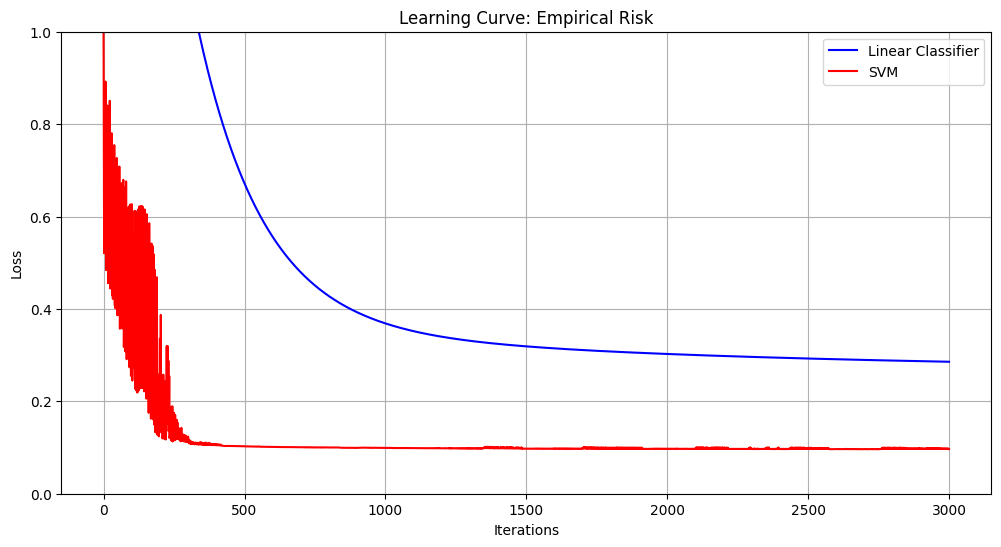

In [7]:
import matplotlib.pyplot as plt

linear_loss_history = linear_model._get_loss_history()
svm_loss_history = svm_model._get_loss_history()

plt.figure(figsize=(12, 6))
plt.ylim(0, 1)
plt.plot(linear_loss_history, label='Linear Classifier', color='blue')
plt.plot(svm_loss_history, label='SVM', color='red')
plt.title("Learning Curve: Empirical Risk")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

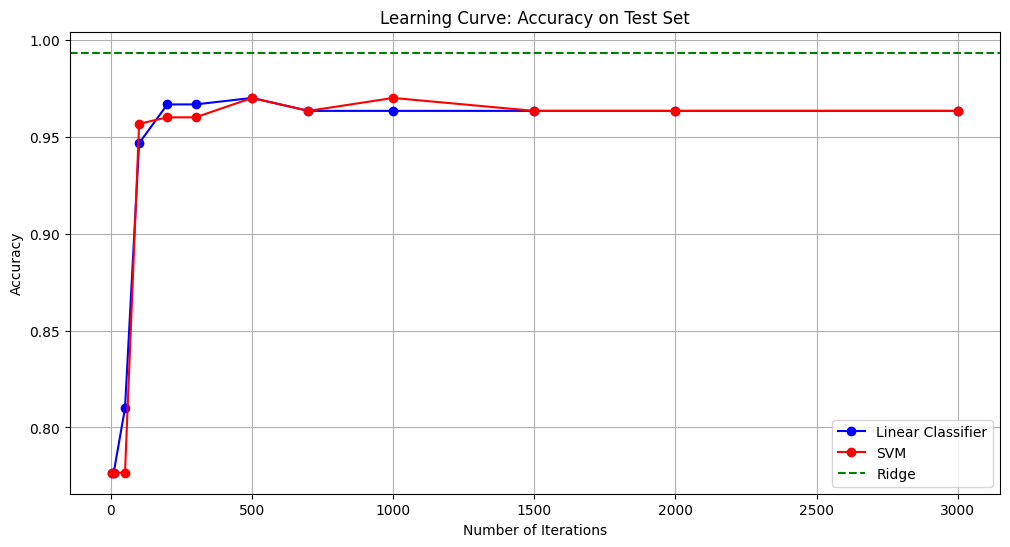

In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from LinearRegressionClassifier import RidgeRegressionClassifier
from sklearn.metrics import accuracy_score

def calculate_accuracy(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ridge_model = RidgeRegressionClassifier(alpha=0.001)

linear_model = LinearClassifierGD(alpha=0, max_iter=3000, loss='squared')

svm_model = SVMClassifier(max_iter=3000, kernel='linear', learning_rate=0.0001)

iterations_list = [5, 10, 50, 100, 200, 300, 500, 700, 1000, 1500, 2000, 3000]

linear_accuracy = []
svm_accuracy = []

for max_iter in iterations_list:
    linear_model.max_iter = max_iter
    linear_model.fit(X_train, y_train)
    linear_acc = calculate_accuracy(linear_model, X_test, y_test)
    linear_accuracy.append(linear_acc)

    svm_model.max_iter = max_iter
    svm_model.fit(X_train, y_train)
    svm_acc = calculate_accuracy(svm_model, X_test, y_test)
    svm_accuracy.append(svm_acc)

ridge_model.fit(X_train, y_train)
ridge_acc = calculate_accuracy(ridge_model, X_test, y_test)

plt.figure(figsize=(12, 6))
plt.plot(iterations_list, linear_accuracy, label="Linear Classifier", color='blue', marker='o')
plt.plot(iterations_list, svm_accuracy, label="SVM", color='red', marker='o')
plt.axhline(ridge_acc, color='green', linestyle='--', label="Ridge")

plt.title("Learning Curve: Accuracy on Test Set")
plt.xlabel("Number of Iterations")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

